In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import ROOT as root
from ROOT import TH2F
from ROOT import TH1F
from openpyxl import Workbook
import pytz
from datetime import datetime
import json
from ROOT import TCanvas
import statistics
import pandas as pd

Welcome to JupyROOT 6.30/04


In [2]:

#root.gStyle.SetOptStat(0)
palette = np.array([3,5,2], dtype=np.int32)
  
  
root.gStyle.SetTitleOffset( 1.3, "z" )
root.gStyle.SetLabelOffset( 0., "z" )
#root.gStyle.SetTitleSize(0.06,"z") 
root.gStyle.SetLabelSize(0.035,"z")
root.gStyle.SetPaintTextFormat("1.1f")
root.gStyle.SetPalette(1)
#root.gStyle.SetPaintTextFormat("1.1f");
root.gStyle.SetPaintTextFormat("4.2f")

   
###################################/ 
## THIS SCRIPT ASSUMES raw voltages in [V] and raw currents in [A] #
## Parameters below are in [V] and [uA]                            #
###################################/

n_wafer = 13 #
n_row = 7 #
n_col = 8 # 
start_wafer = 14 #first wafer number in the dataset
start_row = 1 #the first row of the wafer to be measured
start_col = 1 #the first column of the wafer to be measured 
start_gl_calculation = 5 #VGL calculated only if the number of bias points is larger than this value
save = False
verbose = False
write_json = False #produces the json file needed to upload the tests to the ETL database

dtz = datetime(2026, 5, 15, 12, 0, 0)
dtz = dtz.replace(tzinfo=pytz.utc)
dtz.astimezone(pytz.timezone("Europe/Rome"))

invert_polarity=True

file_qa = root.TFile.Open("/Users/icosivi/Desktop/PRE-SERIE/FBK/PRE-SERIE_FBK_Vendor_QC-TS_CV.root")
tree_qa = file_qa.Get("Tree")

#LC2
low_GL_bias = 15.  # 5 limite basso del fit (in voltaggio)
high_GL_bias = 45.  # 46 limite alto del fit (in voltaggio)
low_bulk_bias = 47.5  # 48 limite basso del fit (in voltaggio)
high_bulk_bias = 49.5  # 50 limite alto del fit (in voltaggio)
low_trail_bias = 55  # 50 limite basso del fit (in voltaggio)
Vbulk_upper_limit = 10. # as defined in Tender, if Vbulk above this value you will get an error message to check the measurement
k_high = 50.
k_low = 10.

bvoltage = False
bvoltage_hist = False
save = False

tests_json = []

vcount_vgl_qa = [[[0 for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
vcount_bump_qa = [[[0 for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
vvgl_qa = [[[0 for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
vbulk_qa = [[[0 for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
vc_raw = [[[[] for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
v_raw = [[[[] for i in range(n_row)] for j in range(n_col)] for k in range(n_wafer)]
hVgl_qa = []
hVbulk_qa = []
hbump_qa = []
hcount_qa = []

# NOTA BENE #
# QC-TS comes in 3 different flavors; it is splitted in side A and B (FBK-LFoundry) #
sensor_type = 1 # 0=PIN,  1=LGAD, 2=1x2 LGAD array

side_number = 1 # The QC-TS has 2 sets of structures: one on the leftside of the array ("A" side_number == 0), one on the rightside ("B" side_number == 1), if side_number != 0,1 the two test structures are averaged in the wafer quality maps
side = "B"
#if side_number == 0:
#    side = "A"
#elif side_number == 1:
#    side = "B"
#else:
#    side = "averaged"

hbulk = TH1F( "vbulk_stats", r"V_{Bulk} (1x1 LGAD) - FBK pre-series", 100, 0, 15 )
hvgl = TH1F( "vgl_stats", r"V_{GL}  (1x1 LGAD) - FBK pre-series", 40, 46, 50 )

for i in range(n_wafer):
    hVgl_qa.append( TH2F( "Vgl_qa_W"+str(i+start_wafer), "VGL on-wafer W"+str(i+start_wafer)+" side "+str(side), n_col,start_col,(start_col+n_col),n_row,start_row,(start_row+n_row) ) )
    hVbulk_qa.append( TH2F( "Vbulk_qa_W"+str(i+start_wafer), "Vbulk on-wafer site W"+str(i+start_wafer)+" side "+str(side), n_col,start_col,(start_col+n_col),n_row,start_row,(start_row+n_row) ) )

dumb_counter = 0. # Total number of sensors/measurements in the root file
non_empty_counter = 0. # Sensors with both I and V arrays having size !=0 (the sensor was in fact measured)
non_zero_counter = 0. # Sensors with both I and V arrays having values !=0 (the sensor was measured and can be bias
good_fit_counter = 0. #Fraction of sensors whose category can be properly defined
cv_quality = bool()

'''
if(sensor_type==0):
 prefix_serial = "FBK_LF1_QC-TS_PIN_"
 sensor = "Prototype PIN"
 sensor_geom = "1x1 PIN"
elif(sensor_type==1):
 prefix_serial = "FBK_LF1_QC-TS_LGAD_"
 sensor = "Prototype LGAD"
 sensor_geom = "1x1 LGAD"
else:
 prefix_serial = "FBK_LF1_QC-TS_1x2_"
 sensor = "Prototype LGAD"
 sensor_geom = "1x2 LGAD"
'''

#vendor = "FBK"
#production = "UFSD-LF"
user = "fsiviero" # cern user of who's uploading the test
location = "FBK-LFoundry" # where the test was performed

if(write_json):
    json_filename="Test_Array_Vendor_CV_"+side

save_path = '/Users/icosivi/Desktop/PRE-SERIE/FBK/'

wb = pd.read_excel('/Users/icosivi/Desktop/PRE-SERIE/FBK/FBK_QC-TS_PRE-SERIES.xlsx') # excel that maps 'serial number --> vendor, batch, wafer, row, column'
  
  

In [3]:
# IMPORTANT: please check the if conditions below and choose whether you want to display only side A/B on the wafer quality maps or average the two (if both have been measured)

for event in tree_qa:
  #if event.type==sensor_type: #if different types of QC-TS are present in your root file
  if event.side==side_number: # use this condition to select one QC-TS side ('A'=0; 'B'=1), only the chosen side will show up on the wafer quality map
  #if True: # use this selection to average 'A' and 'B' on the wafer quality map cell
    dumb_counter+=1
    if(int(event.CPAD.size())>=start_gl_calculation and int(event.V.size())>=start_gl_calculation ):
      non_empty_counter+=1

      if( event.CPAD.at(event.CPAD.size()-1)<0 ): 
        Cpad = [float(-i) for i in event.CPAD]
        for idx, i in enumerate(event.CPAD):  
          if(idx<=event.V.size()-1):
           vc_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(-i))  
        #if(verbose): 
          #print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" with negative current detected. Changing polarity.")
      else:
        Cpad = [i for i in event.CPAD]
        for idx, i in enumerate(event.CPAD):  
          if(idx<=event.V.size()-1):
           vc_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(i))  

      if( event.V.at(event.V.size()-1)<0 ): 
        Vbias = [-i for i in event.V]  
        for idx, i in enumerate(event.V):  
         if(idx<=event.CPAD.size()-1):
           v_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(-i))        
        #if(verbose): 
          #print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" with negative Voltage detected. Changing polarity.")
      else:
        Vbias = [i for i in event.V]
        for idx, i in enumerate(event.V): 
          if(idx<=event.CPAD.size()-1): 
           v_raw[event.wafer-start_wafer][event.column-start_col][event.row-start_row].append(float(i))
           

      non_zero_capacitance = sum(Cpad) 
      non_zero_voltage = sum(Vbias)


      if(non_zero_voltage!=0 and non_zero_capacitance!=0):
        non_zero_counter+=1
    
        cv_quality = True
        VGL_CV = -1000.
        Vbulk_CV = -1000.
      
        V_GL_vector = []
        C_GL_vector = []
        V_GL_vector_error = []
        C_GL_vector_error = []
        V_bulk_vector = []
        C_bulk_vector = []
        V_bulk_vector_error = []
        C_bulk_vector_error = []
        V_trail_vector = []
        C_trail_vector = []
        V_trail_vector_error = []
        C_trail_vector_error = []
        
        ####### VGL calculation #####
        for i in range(len(Cpad)):

          if Vbias[i]>=low_GL_bias and Vbias[i]<=high_GL_bias:
  
            V_GL_vector.append(float(Vbias[i]))
            C_GL_vector.append(1./(Cpad[i]*Cpad[i]))

            sigma_C = (Cpad[i+1]-Cpad[i])/np.sqrt(12)
            V_GL_vector_error.append(0.06)
            C_GL_vector_error.append(2*sigma_C/(Cpad[i]*Cpad[i]*Cpad[i]))
  
  
          if Vbias[i]>=low_bulk_bias and Vbias[i]<=high_bulk_bias:
  
            V_bulk_vector.append(float(Vbias[i]))
            C_bulk_vector.append(1./(Cpad[i]*Cpad[i]))

            sigma_C = (Cpad[i+1]-Cpad[i])/np.sqrt(12)
            V_bulk_vector_error.append(0.06)
            C_bulk_vector_error.append(2*sigma_C/(Cpad[i]*Cpad[i]*Cpad[i]))
          
          #if Vbias[i]>high_bulk_bias[event.wafer-start_wafer] and Vbias[i]<Vbias[len(Vbias)-1]: # orignal method
          if Vbias[i]>low_trail_bias and Vbias[i]<Vbias[len(Vbias)-1]: # a la Matteo
  
            V_trail_vector.append(float(Vbias[i]))
            C_trail_vector.append(1./(Cpad[i]*Cpad[i]))

            sigma_C = (Cpad[i+1]-Cpad[i])/np.sqrt(12)
            V_trail_vector_error.append(0.06)
            C_trail_vector_error.append(2*sigma_C/(Cpad[i]*Cpad[i]*Cpad[i]))
        
        V_GL_vector = np.array(V_GL_vector)
        C_GL_vector = np.array(C_GL_vector)
        V_bulk_vector = np.array(V_bulk_vector)
        C_bulk_vector = np.array(C_bulk_vector)
        V_trail_vector = np.array(V_trail_vector)
        C_trail_vector = np.array(C_trail_vector)
        Vbias = np.array(Vbias)
        Cpad = np.array(Cpad)
        g_GL = root.TGraph(len(V_GL_vector),V_GL_vector,C_GL_vector)
        g_bulk = root.TGraph(len(V_bulk_vector),V_bulk_vector,C_bulk_vector)
        g_trail = root.TGraph(len(V_trail_vector),V_trail_vector,C_trail_vector)
        g_total = root.TGraph(len(Vbias),Vbias,Cpad)

        g_GL.Fit("pol1","Q")
        f_gl = g_GL.GetFunction("pol1")
        chi_gl = f_gl.GetChisquare()/f_gl.GetNDF()
        
        g_bulk.Fit("pol1","Q")
        f_bulk = g_bulk.GetFunction("pol1")
        chi_bulk = f_bulk.GetChisquare()/f_bulk.GetNDF()
        
        g_trail.Fit("pol1","Q")
        f_trail = g_trail.GetFunction("pol1")
        chi_trail = f_trail.GetChisquare()/f_trail.GetNDF()
        
        #print("Chi2: "+str(chi_gl)+" "+str(chi_bulk)+" "+str(chi_trail))
        
        g_GL.SetMarkerStyle(20)
        g_bulk.SetMarkerStyle(20)
        g_trail.SetMarkerStyle(20)
        g_total.SetMarkerStyle(20)
        g_GL.SetLineWidth(0)
        g_bulk.SetLineWidth(0)
        g_trail.SetLineWidth(0)
        g_total.SetLineWidth(0)
        
        mg = root.TMultiGraph()
        mg.Add(g_GL,"lp")
        mg.Add(g_bulk,"cp")
        mg.Add(g_trail,"cp")
        mg.Add(g_total,"cp")
        mg.Draw("apl")
        mg.SaveAs("/Users/icosivi/Desktop/PRE-SERIE/FBK/CV_plots/W"+str(event.wafer)+"_S"+str(event.sensor)+".root")
        
        f_GL = g_GL.GetFunction("pol1")
        f_bulk = g_bulk.GetFunction("pol1")
        f_trail = g_trail.GetFunction("pol1")

        m_GL = f_GL.GetParameter(1)
        q_GL = f_GL.GetParameter(0)
        m_bulk = f_bulk.GetParameter(1)
        q_bulk = f_bulk.GetParameter(0)
        m_trail = f_trail.GetParameter(1)
        q_trail = f_trail.GetParameter(0)


        VGL_CV = (q_bulk-q_GL)/(m_GL-m_bulk)
        Vbulk_CV = (q_trail-q_bulk)/(m_bulk-m_trail) - VGL_CV
        print(str(VGL_CV)+" "+str(Vbulk_CV))
        
        if( VGL_CV>low_GL_bias and VGL_CV<high_bulk_bias and Vbulk_CV>0. and Vbulk_CV<Vbulk_upper_limit ):
          good_fit_counter += 1
          vvgl_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += VGL_CV
          vbulk_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += Vbulk_CV
          vcount_bump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += 1 
          hbulk.Fill(Vbulk_CV)
          hvgl.Fill(VGL_CV)
        else: 
          vcount_bump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += -1000
          if(verbose):
            print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" : VGL could not be calculated. PLEASE CHECK.")
      else:
        vcount_bump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += -1000
        if(verbose):
          print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+" has Voltage and/or Capacitance always equal to zero. PLEASE CHECK.")
    else:
      vcount_bump_qa[event.wafer-start_wafer][event.column-start_col][event.row-start_row] += -1000
      if(verbose):
        print("Sensor from wafer "+str(event.wafer)+" row "+str(event.row)+" column "+str(event.column)+": Voltage and/or Capacitance vectors have less than "+str(start_gl_calculation)+" elements. PLEASE CHECK.")
        
print("Succesful fits: "+str(float(good_fit_counter/dumb_counter)*100)+" %")
print("Succesful fits (only non empty CVs): "+str(float(good_fit_counter/non_zero_counter)*100)+" %")
print("Non empty CVs: "+str(float(non_zero_counter/dumb_counter)*100)+" %")

with open(save_path+"Vbulk_list.json", 'w') as f:
   json.dump(vbulk_qa, f, indent=4)

with open(save_path+"VGL_list.json", 'w') as f:
   json.dump(vvgl_qa, f, indent=4)

48.065275611341214 3.242480662719359
47.89083942064757 1.6711741895156393
48.07614383444144 3.8503857798990992
47.81225807380319 1.7979392585106453
48.09952010126391 4.804252099503664
47.99093763841242 1.7706156161497262
47.79319462404534 1.4946170923133408
48.062227408626654 41.951389148173206
48.0733336858106 3.073030711671869
48.066045360693906 3.32921414196489
48.102500733167 22.156039035134263
47.28312477634353 -3814.959241296741
47.95873011335115 1.609857596393823
47.976740855947426 1.6586178070873245
48.096091352124546 29.49339821809471
48.06158464874897 2.4254789421305674
47.84565141640144 1.5523767195590352
47.81395684744995 1.7176953563868622
48.03787944731821 2.15507456908324
48.08345617973122 3.093520200074501
48.00633010980831 1.7669623559291594
47.92993180790882 1.5384684398984234
48.099955568021876 3.694861534789233
48.08722423993928 3.0306426656487986
48.00725848015688 1.8730426829512297
46.57437805190953 2.592469244348571
47.97033572939395 1.7172384711713136
48.0870880

Info in <TCanvas::MakeDefCanvas>:  created default TCanvas with name c1
Info in <TMultiGraph::SaveAs>: ROOT file /Users/icosivi/Desktop/PRE-SERIE/FBK/CV_plots/W20_S1.root has been created
Info in <TMultiGraph::SaveAs>: ROOT file /Users/icosivi/Desktop/PRE-SERIE/FBK/CV_plots/W20_S2.root has been created
Info in <TMultiGraph::SaveAs>: ROOT file /Users/icosivi/Desktop/PRE-SERIE/FBK/CV_plots/W20_S3.root has been created
Info in <TMultiGraph::SaveAs>: ROOT file /Users/icosivi/Desktop/PRE-SERIE/FBK/CV_plots/W20_S4.root has been created
Info in <TMultiGraph::SaveAs>: ROOT file /Users/icosivi/Desktop/PRE-SERIE/FBK/CV_plots/W20_S5.root has been created
Info in <TMultiGraph::SaveAs>: ROOT file /Users/icosivi/Desktop/PRE-SERIE/FBK/CV_plots/W20_S6.root has been created
Info in <TMultiGraph::SaveAs>: ROOT file /Users/icosivi/Desktop/PRE-SERIE/FBK/CV_plots/W20_S7.root has been created
Info in <TMultiGraph::SaveAs>: ROOT file /Users/icosivi/Desktop/PRE-SERIE/FBK/CV_plots/W20_S8.root has been created


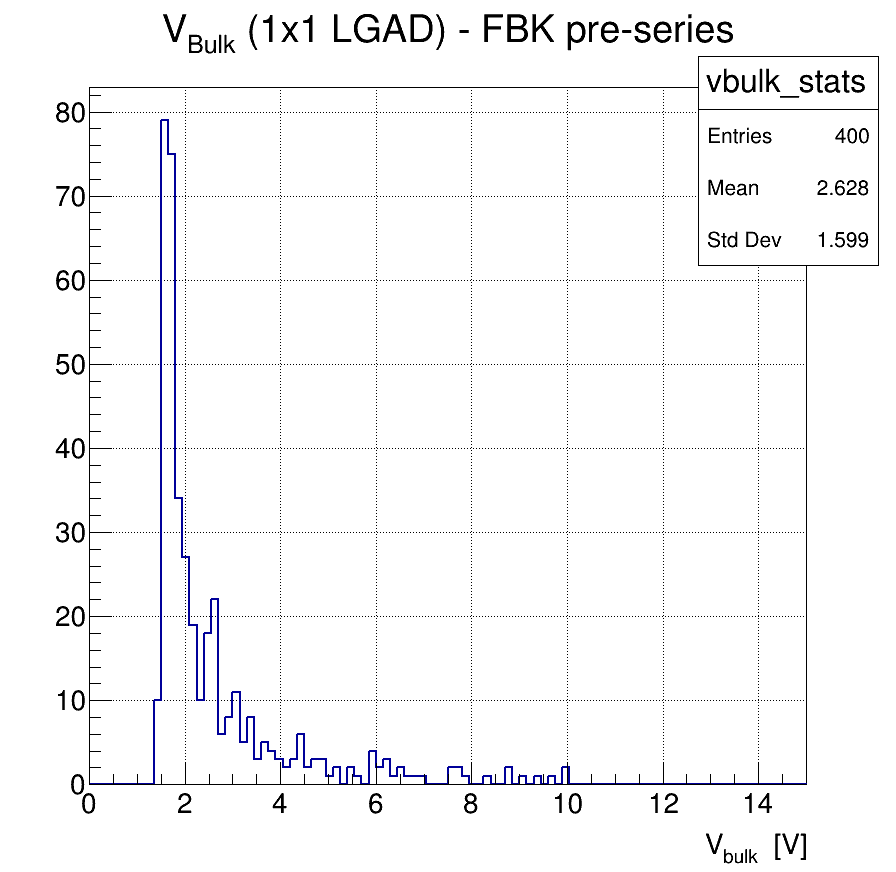

In [11]:
root.gStyle.SetOptFit(111)          
cx = TCanvas( "c_vbulk", "c_vbulk", 900,900)
cx.cd()
gaus_func1 = root.TF1("gaus_vbulk", "gaus", 0, 5)
hbulk.GetXaxis().SetTitle(r"V_{bulk}  [V]")
hbulk.GetXaxis().SetTitleOffset(1.3)
hbulk.SetLineWidth(2)
hbulk.Draw()
#hbulk.Fit(gaus_func1,'R')
root.gPad.SetGrid(1,1)
root.gPad.Draw()
cx.Modified()
cx.Update()

****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      66.2414
NDf                       =            9
Edm                       =  4.19774e-09
NCalls                    =           95
Constant                  =      110.339   +/-   12.2429     
Mean                      =       47.991   +/-   0.0086916   
Sigma                     =     0.124023   +/-   0.0138542    	 (limited)


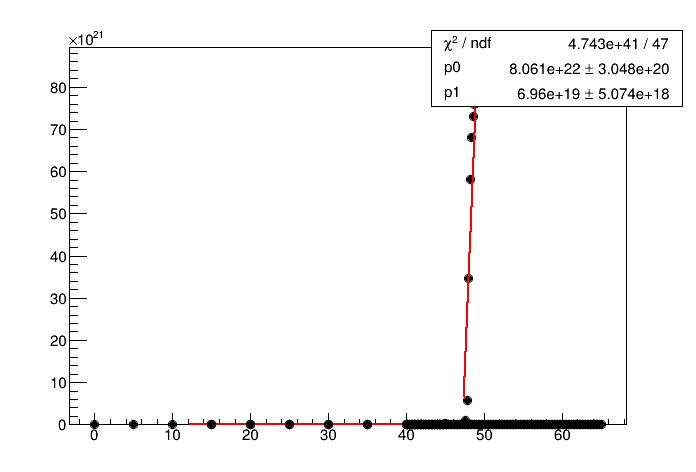

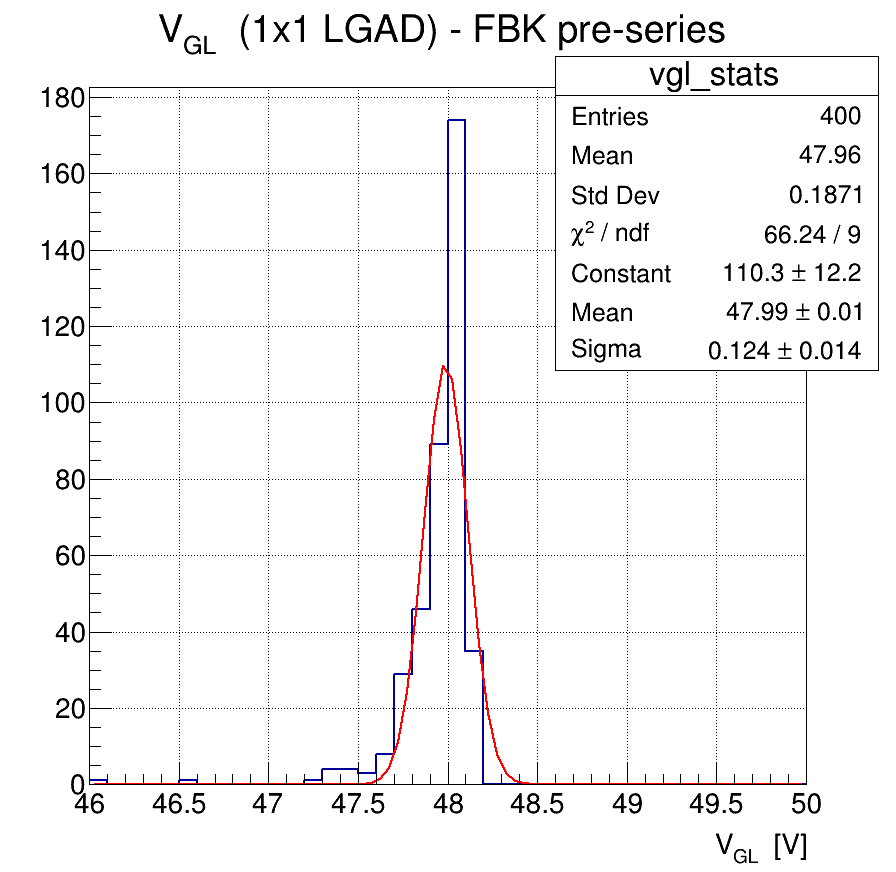

In [4]:
root.gStyle.SetOptFit(111)  
cy = TCanvas( "c_vgl", "c_vgl", 900,900)
cy.cd()
gaus_func1 = root.TF1("gaus_vgl", "gaus", 45, 50)
hvgl.GetXaxis().SetTitle(r"V_{GL}  [V]")
hvgl.GetXaxis().SetTitleOffset(1.3)
hvgl.SetLineWidth(2)
hvgl.Draw()
hvgl.Fit(gaus_func1,'R')
root.gPad.SetGrid(1,1)
root.gPad.Draw()
cy.Modified()
cy.Update()

In [9]:
wafer_values = []
for entry in tree_qa:
        wafer_values.append(entry.wafer-start_wafer)
        #wafer_real_numbers.append(entry.wafer)

wafer_real_numbers = [i+start_wafer for i in range(n_wafer)]
vgl_list = [[] for i in range(n_wafer)]
vbulk_list = [[] for i in range(n_wafer)]

In [6]:
for i in range(n_wafer):
    for j in range(n_col):
        for k in range(n_row):
          if i in wafer_values:
          #if( i<20 ):
             if(vcount_bump_qa[i][j][k] > 0):
               hVgl_qa[i].Fill( j+start_col, k+start_row, vvgl_qa[i][j][k]/vcount_bump_qa[i][j][k] )
               hVbulk_qa[i].Fill( j+start_col, k+start_row, vbulk_qa[i][j][k]/vcount_bump_qa[i][j][k] )
               vgl_list[i].append(vvgl_qa[i][j][k]/vcount_bump_qa[i][j][k])
               vbulk_list[i].append(vbulk_qa[i][j][k]/vcount_bump_qa[i][j][k])
               
               pippo = {'component': str(wb[(wb['Wafer'] == event.wafer) & (wb['Row'] == event.row) & (wb['Column'] == event.column)]['SerialNumber'].iloc[0]),
                        'name': 'Sensor Test Array CV',
                        'measurement_date': dtz.isoformat(), #year, month, day, hour, minute, second
                        'location': location,
                        'user_created': user,
                        'version': 'v0',
                        'vgl': vvgl_qa[i][j][k]/vcount_bump_qa[i][j][k],
                        'vbulk': vbulk_qa[i][j][k]/vcount_bump_qa[i][j][k],
                        'side': side,
                        'geometry': '1x1 LGAD',
                        'gain category': None,
                        'voltage': v_raw[i][j][k],
                        'capacitance': vc_raw[i][j][k]
                       }
               
               tests_json.append(pippo)
  
             if(vcount_bump_qa[i][j][k]<0): 
               pippo = {'component': str(wb[(wb['Wafer'] == event.wafer) & (wb['Row'] == event.row) & (wb['Column'] == event.column)]['SerialNumber'].iloc[0]),
                        'name': 'Sensor Test Array CV',
                        'measurement_date': dtz.isoformat(), #year, month, day, hour, minute, second
                        'location': location,
                        'user_created': user,
                        'version': 'v0',
                        'vgl': None,
                        'vbulk': None,
                        'side': side,
                        'geometry': '1x1 LGAD',
                        'gain category': None,
                        'voltage': v_raw[i][j][k],
                        'capacitance': vc_raw[i][j][k]
                       }
               
               tests_json.append(pippo)

if write_json:
 with open(save_path+json_filename+".json", 'w') as f:
   json.dump(tests_json, f, indent=4)

In [7]:
mean_array_bulk = []
sigma_array_bulk = []
mean_array_vgl = []
sigma_array_vgl = []

for i in vbulk_list:
  if not len(i)==0:
    mean_array_bulk.append(statistics.mean(i))
    sigma_array_bulk.append(statistics.stdev(i))
  else:
    mean_array_bulk.append(0)
    sigma_array_bulk.append(0)


for v in vgl_list:
  if not len(v)==0:
    mean_array_vgl.append(statistics.mean(v))
    sigma_array_vgl.append(statistics.stdev(v))
  else:
    mean_array_vgl.append(0)
    sigma_array_vgl.append(0)

with open(save_path+"mean_Vbulk.json", 'w') as f:
   json.dump(mean_array_bulk, f, indent=4)
   
with open(save_path+"sigma_Vbulk.json", 'w') as f:
   json.dump(mean_array_bulk, f, indent=4)

with open(save_path+"mean_VGL.json", 'w') as f:
   json.dump(mean_array_vgl, f, indent=4)

with open(save_path+"sigma_VGL.json", 'w') as f:
   json.dump(sigma_array_vgl, f, indent=4)

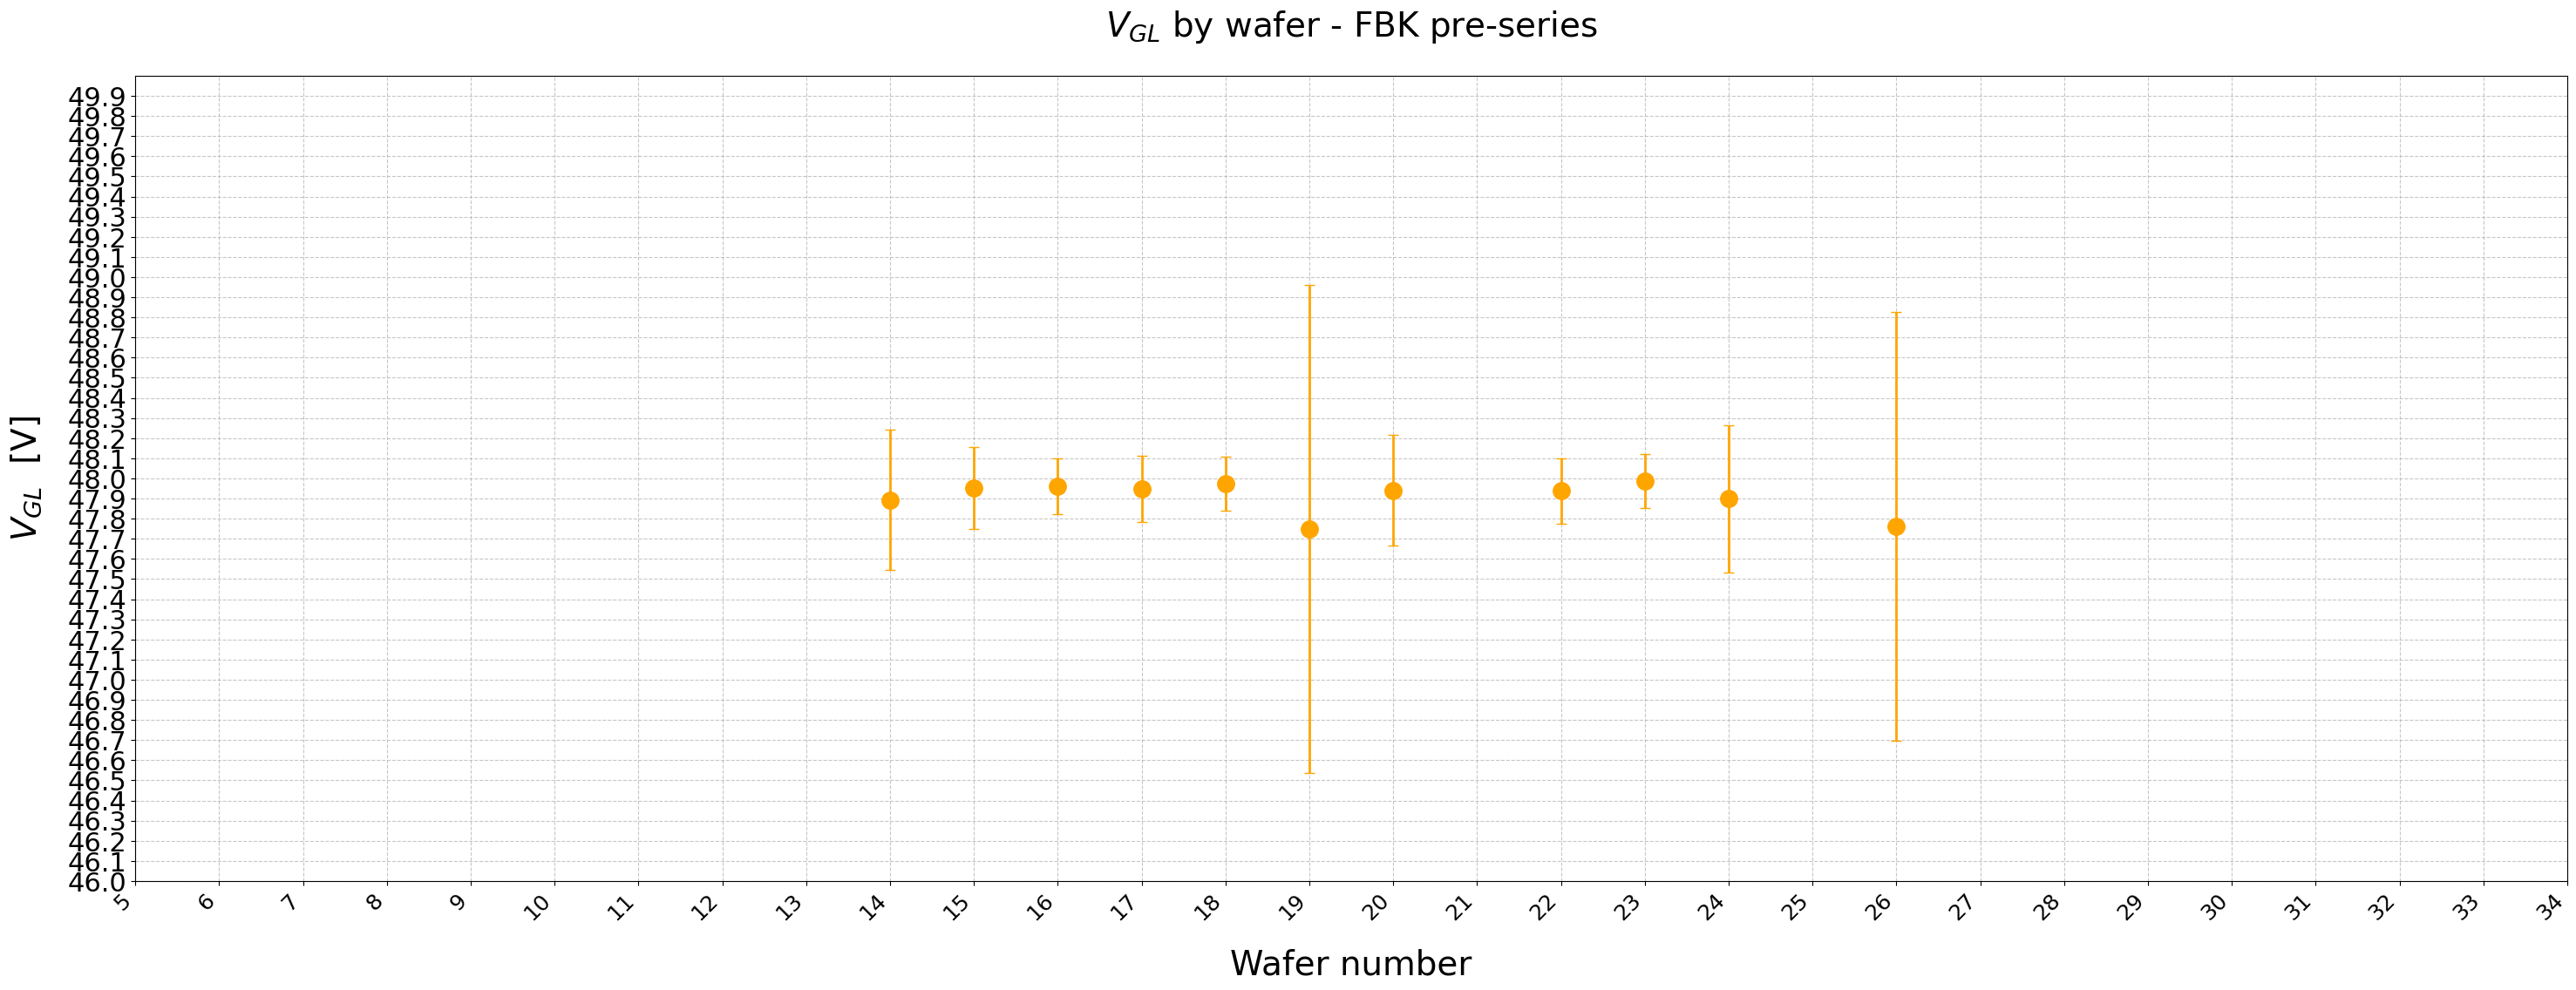

In [10]:
plt.figure(figsize=(36, 12))
plt.errorbar(wafer_real_numbers, mean_array_vgl,yerr=sigma_array_vgl,linewidth=0,elinewidth=2,capsize=4,fmt='o-',markersize=14,color='orange')
plt.xlabel('Wafer number',fontsize=28,labelpad=20)
plt.ylabel("$V_{GL}$  [V]",fontsize=28,labelpad=20)
plt.ylim(46,50)
plt.title('$V_{GL}$ by wafer - FBK pre-series',fontsize=28, y=1.04)
y_ticks_m = np.arange(46, 50, 0.1)
x_ticks_m = np.arange(5, 35, 1)
plt.yticks(y_ticks_m,fontsize=22)
plt.xticks(x_ticks_m, fontsize=18, rotation=45, ha='right')
#plt.xticks(fontsize=14)
#plt.yticks(fontsize=14)
plt.grid(True,linestyle='--', alpha=0.7)
plt.show()

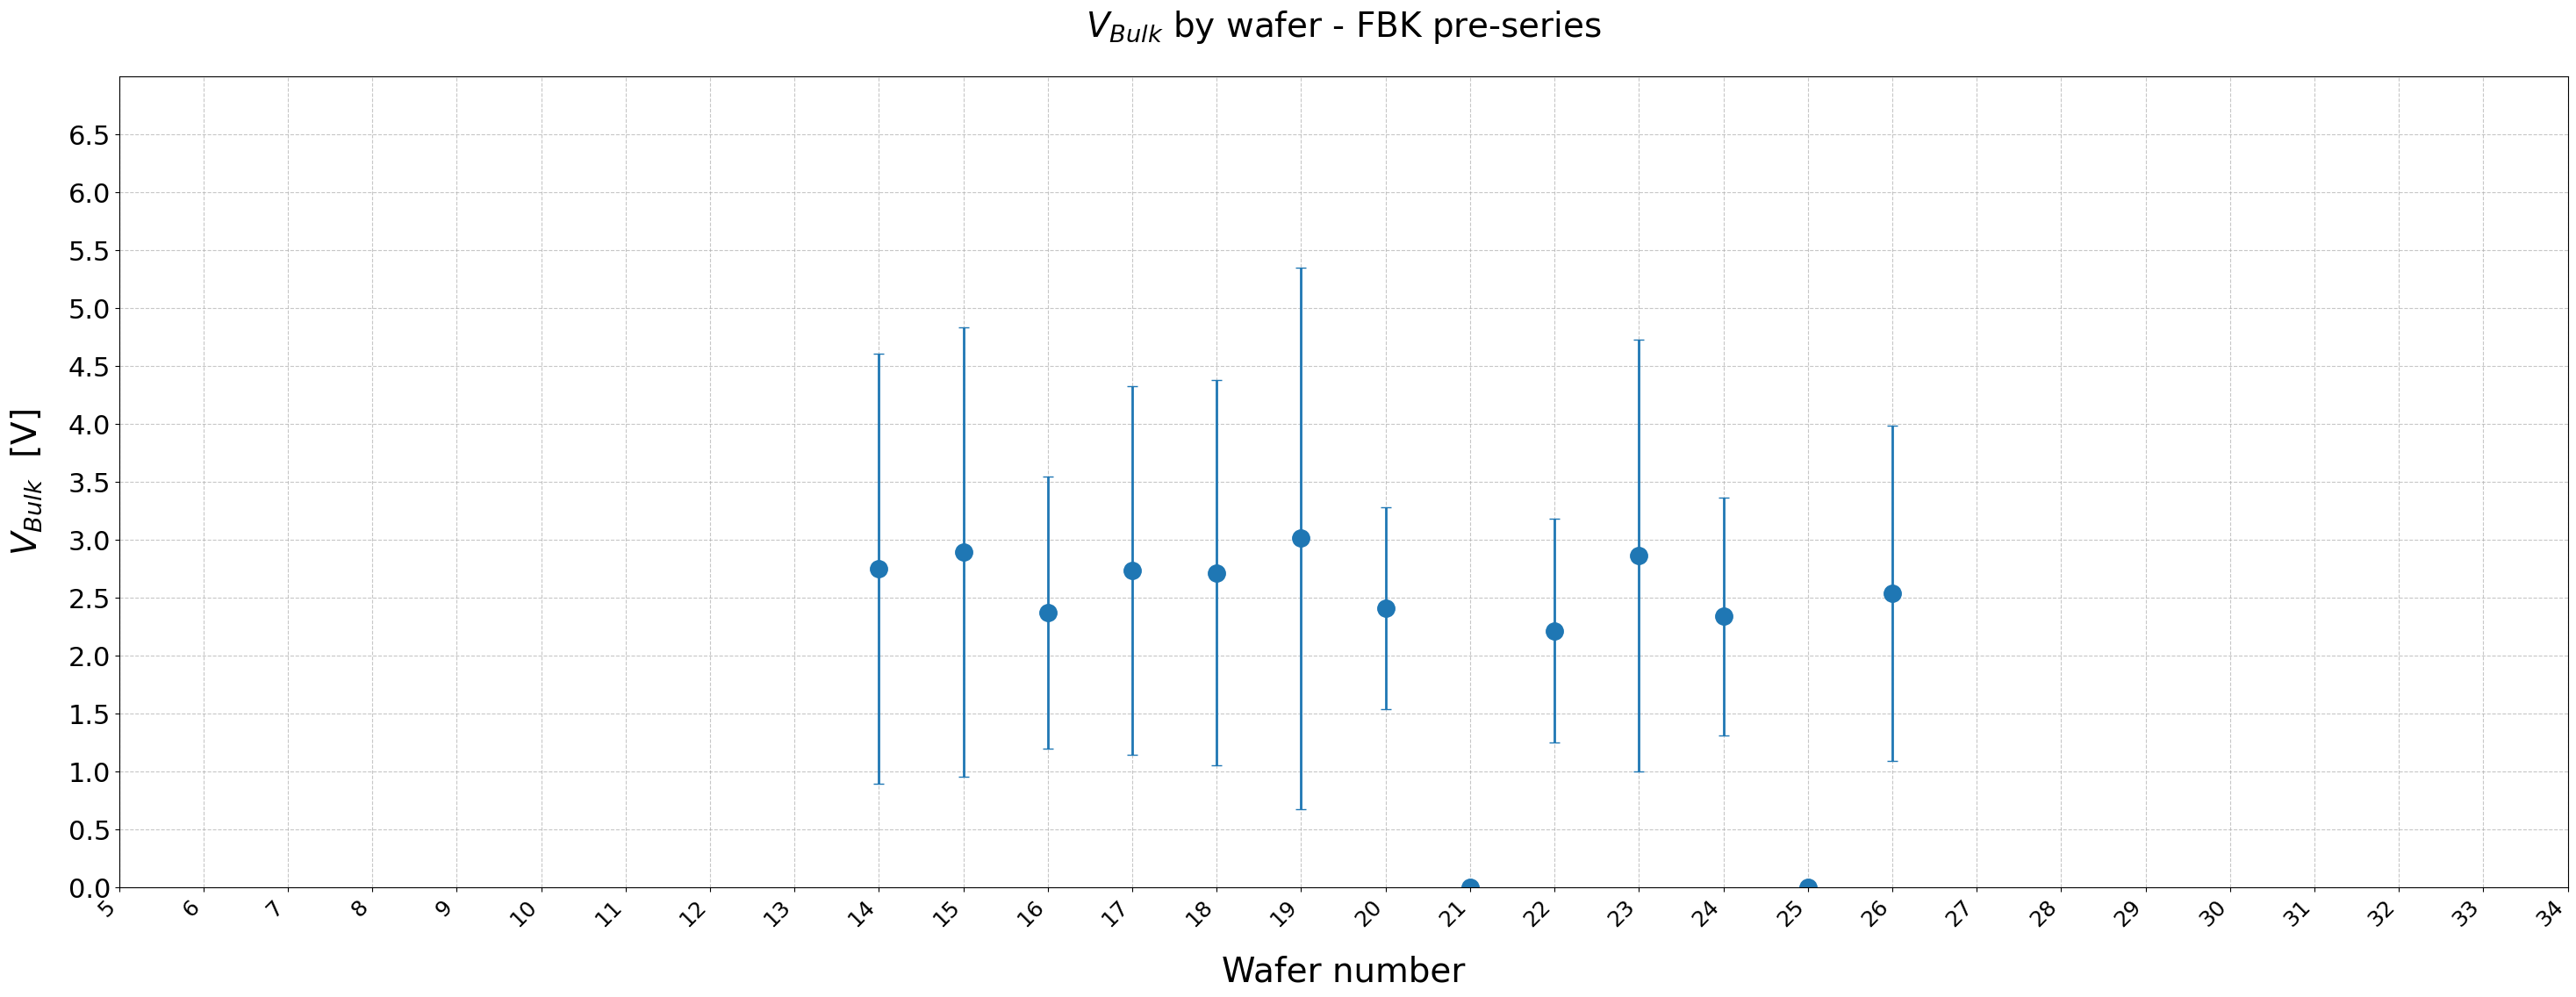

In [14]:
plt.figure(figsize=(36, 12))
plt.errorbar(wafer_real_numbers, mean_array_bulk,yerr=sigma_array_bulk,linewidth=0,elinewidth=2,capsize=4,fmt='o-',markersize=14)
plt.xlabel('Wafer number',fontsize=28,labelpad=20)
plt.ylabel("$V_{Bulk}$  [V]",fontsize=28,labelpad=20)
plt.ylim(0,7)
plt.title('$V_{Bulk}$ by wafer - FBK pre-series',fontsize=28, y=1.04)
y_ticks_m = np.arange(0, 7, 0.5)
x_ticks_m = np.arange(5, 35, 1)
plt.yticks(y_ticks_m,fontsize=22)
plt.xticks(x_ticks_m, fontsize=18, rotation=45, ha='right')
#plt.xticks(fontsize=14)
#plt.yticks(fontsize=14)
plt.grid(True,linestyle='--', alpha=0.7)
plt.show()

In [ ]:
cC = []

for i in range(n_wafer):
 #if( i==0 ):
 if( i<20 ):
    cC.append(root.TCanvas("c_C_W"+str(i+start_wafer), "c VGL_W"+str(i+start_wafer), 1000,1000))
    hVgl_qa[i].GetZaxis().SetRangeUser( 20., 55. ) # Tender acceptance ranges
    hVgl_qa[i].GetZaxis().SetTitle("[V]")
    hVgl_qa[i].GetXaxis().SetTitle("column") 
    hVgl_qa[i].GetYaxis().SetTitle("row")
    hVgl_qa[i].SetMarkerSize(3.)

    root.gStyle.SetPaintTextFormat("1.1f")
    #cV.append(root.TCanvas("c_V_W"+str(i+1), "c VBD_W"+str(i+1), 1000,1000))
    cC[i].SetRightMargin(0.15)
    cC[i].cd()
    hVgl_qa[i].SetMarkerSize(0.9)
    hVgl_qa[i].Draw("textcolz")
    root.gPad.SetGrid(1,1)
    root.gPad.Update()
    cC[i].Update()
    hVgl_qa[i].GetXaxis().SetNdivisions(n_col)
    hVgl_qa[i].GetYaxis().SetNdivisions(n_row)
  
    if(save): 
      cC[i].SaveAs(save_path+"VGL_W"+str(i+start_wafer)+".png")    

In [ ]:
cD = []

for i in range(n_wafer):
 #if( i==0 ):
 if( i<20 ):
    cD.append(root.TCanvas("c_D_W"+str(i+start_wafer), "c Vbulk_W"+str(i+start_wafer), 1000,1000))
    hVbulk_qa[i].GetZaxis().SetRangeUser( 0., 10. ) # Tender acceptance ranges
    hVbulk_qa[i].GetZaxis().SetTitle("[V]")
    hVbulk_qa[i].GetXaxis().SetTitle("column") 
    hVbulk_qa[i].GetYaxis().SetTitle("row")
    hVbulk_qa[i].SetMarkerSize(3.)

    root.gStyle.SetPaintTextFormat("1.1f")
    #cV.append(root.TCanvas("c_V_W"+str(i+1), "c VBD_W"+str(i+1), 1000,1000))
    cD[i].SetRightMargin(0.15)
    cD[i].cd()
    hVbulk_qa[i].SetMarkerSize(0.9)
    hVbulk_qa[i].Draw("textcolz")
    root.gPad.SetGrid(1,1)
    root.gPad.Update()
    cD[i].Update()
    hVbulk_qa[i].GetXaxis().SetNdivisions(n_col)
    hVbulk_qa[i].GetYaxis().SetNdivisions(n_row)
  
    if(save): 
      cD[i].SaveAs(save_path+"Vbulk_W"+str(i+start_wafer)+"_side_"+str(side)+".png")   